# ALK2011HSCC: reachable sets of linear systems with uncertain inputs

Althoff, M., Le Guernic, C., & Krogh, B. H. (2011). Reachable set computation for uncertain time-varying linear systems. *HSCC 2011*, pp. 93-102.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ASAG-ISCAS/PyBDR/blob/master/examples/alk2011hscc.ipynb)

Each case is independent. Some cases run for several minutes; the outputs stored in this notebook show the results without running it.

In [1]:
# install PyBDR when running on Colab (skipped when it is already installed)
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pybdr") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pybdr @ git+https://github.com/ASAG-ISCAS/PyBDR"])

In [2]:
%matplotlib inline

import numpy as np
from pybdr.geometry import Zonotope, Geometry, Interval
from pybdr.dynamic_system import LinSys
from pybdr.algorithm import ALK2011HSCC
from pybdr.geometry.operation import cvt2, boundary
from pybdr.util.visualization import plot, plot_cmp

## Case 0

model `lin_dyn`, `t_end = 5`, `step = 0.01`, boundary analysis (`reach_parallel`)

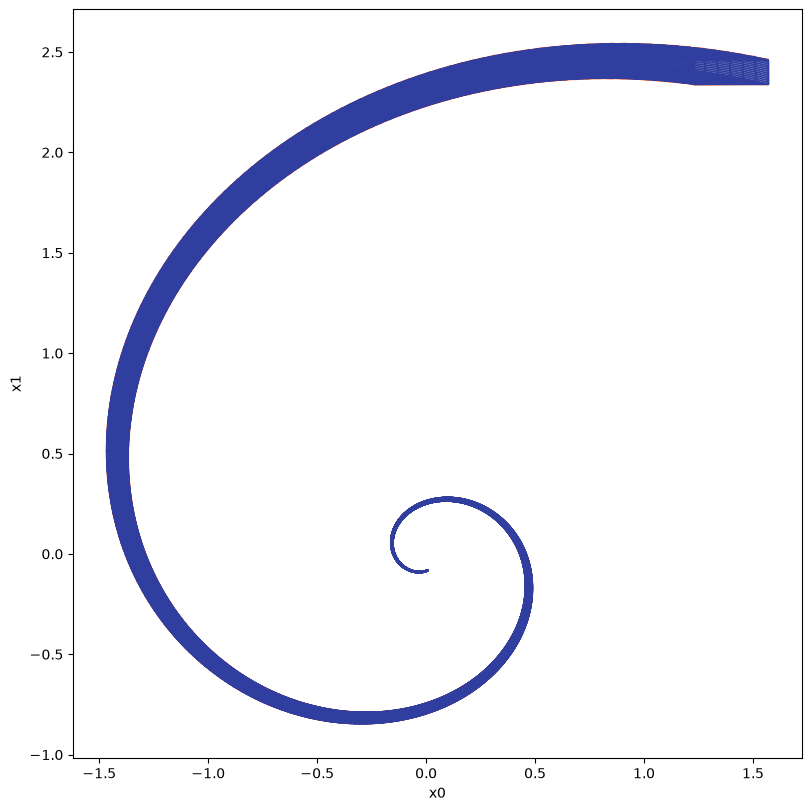

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [3]:
a = np.array([[-0.7, -2], [2, -0.7]])
b = np.identity(2)

lin_dyn = LinSys(a, b)

# settings for the computation
options = ALK2011HSCC.Options()
options.t_end = 5
options.step = 0.01
options.taylor_terms = 4
options.tensor_order = 3

options.u = Zonotope.zero(2, 1)
options.u_trans = np.zeros(2)

# settings for using Zonotope
Zonotope.ORDER = 50
Zonotope.INTERMEDIATE_ORDER = 50
Zonotope.ERROR_ORDER = 20

z = Interval([1.23, 2.34], [1.57, 2.46])

x0 = cvt2(z, Geometry.TYPE.ZONOTOPE)
xs = boundary(z, 0.01, Geometry.TYPE.ZONOTOPE)

ri_without_bound, rp_without_bound = ALK2011HSCC.reach(lin_dyn, options, x0)
ri_with_bound, rp_with_bound = ALK2011HSCC.reach_parallel(lin_dyn, options, xs)

# visualize the results
plot_cmp([ri_without_bound, ri_with_bound], [0, 1], cs=["#FF5722", "#303F9F"])